<a href="https://colab.research.google.com/github/AKChumba/NamPulse/blob/ml-classifier/ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Sentiment Analysis Pipeline

This notebook demonstrates a complete Natural Language Processing (NLP) workflow for sentiment analysis and emotion classification.

The workflow includes:
1. **Data Exploration & Preprocessing:** Loading a custom dataset, cleaning it, and analyzing text length distributions.
2. **Feature Extraction:** Using a pre-trained transformer (`roberta-base`) to extract deep contextual embeddings.
3. **Baseline Modeling:** Training traditional machine learning models (Logistic Regression and Support Vector Machines) on the extracted embeddings to establish a performance baseline.


In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from datasets import load_dataset
from datasets import Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import classification_report, accuracy_score, f1_score


## 2. Loading the Custom Dataset
Next, we mount Google Drive to access our specific dataset (`nampulse_clean.parquet`). We will transition from the standard dataset to this custom data for the remainder of our pipeline.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Learning Folder/nampulse_clean.parquet'
dataf = pd.read_parquet(file_path)
display(dataf.head())

,tweet_id,created_at,label,label_source,topic_group,text_raw,text_clean,language,language_conf,is_english,is_code_switched,languages_found,other_lang_words,dup_group_size,n_words,text_key
0,1467815753,2009-04-07 05:21:04+00:00,negative,emoticon,unknown,Meh... Almost Lover is the exception... this t...,Meh... Almost Lover is the exception... this t...,en,0.944,True,False,en,0,1,13,meh almost lover is the exception this track g...
1,1467815924,2009-04-07 05:21:07+00:00,negative,emoticon,unknown,@alielayus I want to go to promote GEAR AND GR...,I want to go to promote GEAR AND GROOVE but un...,en,0.986,True,False,en,0,1,26,i want to go to promote gear and groove but un...
2,1467821338,2009-04-07 05:22:30+00:00,negative,emoticon,unknown,Put vacation photos online a few yrs ago. PC c...,Put vacation photos online a few yrs ago. PC c...,en,0.969,True,False,en,0,1,19,put vacation photos online a few yrs ago pc cr...
3,1467822489,2009-04-07 05:22:49+00:00,positive,emoticon,unknown,"@tommcfly ah, congrats mr fletcher for finally...","ah, congrats mr fletcher for finally joining t...",en,0.913,True,False,en,0,1,8,ah congrats mr fletcher for finally joining tw...
4,1467822899,2009-04-07 05:22:58+00:00,positive,emoticon,unknown,@michellardi i really don't know. i think its ...,i really don't know. i think its Globe! yeah! ...,tl,0.762,False,True,tl|en,4,1,22,i really don t know i think its globe yeah san...


In [ ]:
dataf.columns

Index(['tweet_id', 'created_at', 'label', 'label_source', 'topic_group',
       'text_raw', 'text_clean', 'language', 'language_conf', 'is_english',
       'is_code_switched', 'languages_found', 'other_lang_words',
       'dup_group_size', 'n_words', 'text_key'],
      dtype='object')

## 3. Data Cleaning and Preprocessing
The custom dataset contains many columns. The `process_data` function filters down to the essential columns (like `text` and `label`), renames them for compatibility with Hugging Face tools, and extracts the date and time for potential time-series analysis.

In [ ]:
def process_data(df):
    columns = ['tweet_id','created_at','label','label_source','topic_group','text_clean','language']
    df = df[columns].copy()
    df = df.rename(columns={'text_clean': 'text'})
    df['date'] = df['created_at'].dt.date
    df['time'] = df['created_at'].dt.time
    df = df.drop(columns=['created_at'])
    return df

# Note: if you run this cell again, make sure to reload the original dataf first
# since the previous run already renamed 'text_clean' and now dropped 'created_at'.
try:
    dataf = process_data(dataf)
    display(dataf.head())
except KeyError as e:
    print(f"KeyError: {e}. You might need to reload the original dataf first.")

,tweet_id,label,label_source,topic_group,text,language,date,time
0,1467815753,negative,emoticon,unknown,Meh... Almost Lover is the exception... this t...,en,2009-04-07,05:21:04
1,1467815924,negative,emoticon,unknown,I want to go to promote GEAR AND GROOVE but un...,en,2009-04-07,05:21:07
2,1467821338,negative,emoticon,unknown,Put vacation photos online a few yrs ago. PC c...,en,2009-04-07,05:22:30
3,1467822489,positive,emoticon,unknown,"ah, congrats mr fletcher for finally joining t...",en,2009-04-07,05:22:49
4,1467822899,positive,emoticon,unknown,i really don't know. i think its Globe! yeah! ...,tl,2009-04-07,05:22:58


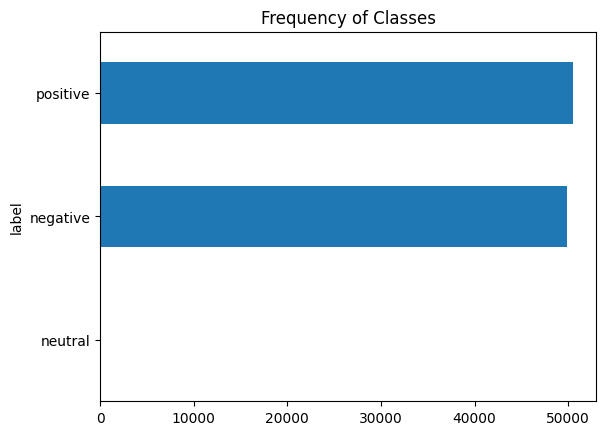

In [ ]:
dataf['label'].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

In [ ]:
len(dataf)

100493

In [ ]:
dataf.isna().sum()

,0
tweet_id,0
label,0
label_source,0
topic_group,0
text,0
language,0
date,0
time,0


In [ ]:
dataf['tweet_id'].duplicated().sum()

np.int64(0)

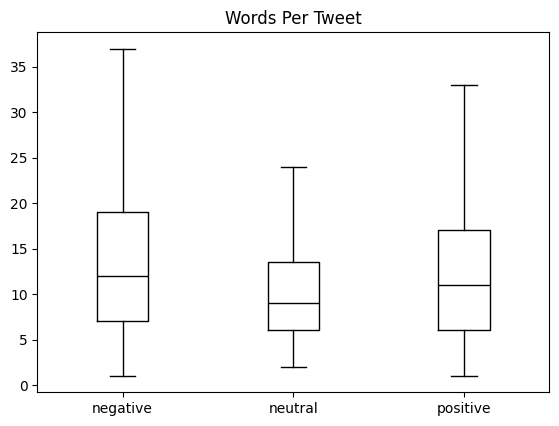

In [ ]:
dataf["Words Per Tweet"] = dataf["text"].str.split().apply(len)
dataf.boxplot("Words Per Tweet", by="label", grid=False,
showfliers=False, color="black")
plt.suptitle("")
plt.xlabel("")
plt.show()

## 4. Dataset Splitting
To properly evaluate our models, we must split the data. We use a 70% Train, 15% Validation, and 15% Test split. The validation set helps tune hyperparameters and prevents overfitting, while the test set provides a final, unbiased metric of our model's performance.

In [ ]:
def create_and_split_dataset(df, val_size=0.15, test_size=0.15, seed=42):
    # First create a Dataset from the pandas dataframe
    dataset = Dataset.from_pandas(df, preserve_index=False)

    # Calculate the proportion of the test set relative to the entire dataset
    # The remaining will be train + validation
    test_prop = test_size

    # Split into (train + validation) and test
    train_val_test = dataset.train_test_split(test_size=test_prop, seed=seed)

    # Calculate the proportion of the validation set relative to the remaining (train + validation)
    # If val_size is 0.15 and test_size is 0.15, train_val_test['train'] is 0.85 of the total.
    # We need 0.15 of the total to be validation. So val_prop = 0.15 / 0.85
    val_prop = val_size / (1.0 - test_size)

    # Split the (train + validation) into train and validation
    train_val = train_val_test['train'].train_test_split(test_size=val_prop, seed=seed)

    # Combine everything into a single DatasetDict
    from datasets import DatasetDict
    dataset_split = DatasetDict({
        'train': train_val['train'],
        'validation': train_val['test'],
        'test': train_val_test['test']
    })

    return dataset_split

nampluse = create_and_split_dataset(dataf, val_size=0.15, test_size=0.15)
train_ds1 = nampluse['train']
val_ds1 = nampluse['validation']
test_ds1 = nampluse['test']
nampluse


DatasetDict({
    train: Dataset({
        features: ['tweet_id', 'label', 'label_source', 'topic_group', 'text', 'language', 'date', 'time', 'Words Per Tweet'],
        num_rows: 70345
    })
    validation: Dataset({
        features: ['tweet_id', 'label', 'label_source', 'topic_group', 'text', 'language', 'date', 'time', 'Words Per Tweet'],
        num_rows: 15074
    })
    test: Dataset({
        features: ['tweet_id', 'label', 'label_source', 'topic_group', 'text', 'language', 'date', 'time', 'Words Per Tweet'],
        num_rows: 15074
    })
})

## 5. Tokenization
Transformer models cannot read raw text. We use the `AutoTokenizer` for `roberta-base` to convert strings into arrays of integers (`input_ids`) and create `attention_mask` arrays so the model knows which tokens are real words and which are just padding.

In [ ]:


def load_transformer_model(ckpt_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(ckpt_name)
    model = AutoModel.from_pretrained(ckpt_name).to(device)
    print(f"Loaded {ckpt_name} successfully on {device}!")
    return tokenizer, model, device

model_ckpt = "roberta-base"
roberta_tokenizer, roberta_model, device = load_transformer_model(model_ckpt)

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded roberta-base successfully on cpu!


In [ ]:
def tokenize_roberta(batch):
  return roberta_tokenizer(batch["text"], padding=True, truncation=True)

print(tokenize_roberta(nampluse["train"][:2]))

{'input_ids': [[0, 298, 11695, 2980, 24, 4, 38, 581, 27789, 7, 120, 173, 4, 2, 1, 1, 1, 1], [0, 44049, 154, 41, 1437, 12646, 3895, 734, 6908, 33, 7, 386, 4835, 540, 9, 106, 600, 2]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [ ]:
nampluse_encoded_roberta = nampluse.map(tokenize_roberta, batched=True, batch_size=None)
display(nampluse_encoded_roberta["train"].column_names)

Map:   0%|          | 0/70345 [00:00<?, ? examples/s]

Map:   0%|          | 0/15074 [00:00<?, ? examples/s]

Map:   0%|          | 0/15074 [00:00<?, ? examples/s]

['tweet_id',
 'label',
 'label_source',
 'topic_group',
 'text',
 'language',
 'date',
 'time',
 'Words Per Tweet',
 'input_ids',
 'attention_mask']

In [ ]:
text = "this is a test"
inputs = tokenizer(text, return_tensors="pt")
print(f"Input tensor shape: {inputs['input_ids'].size()}")

Input tensor shape: torch.Size([1, 6])


In [ ]:
def get_model_outputs(inputs, model, device):
    # Move inputs to the correct device (CPU or GPU)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Pass the inputs through the model without calculating gradients
    with torch.no_grad():
        outputs = model(**inputs)

    return outputs

# Test the function using the outputs from load_transformer_model
outputs = get_model_outputs(inputs, roberta_model, device)
print("Last hidden state shape:", outputs.last_hidden_state.shape)

Last hidden state shape: torch.Size([1, 6, 768])


In [ ]:
print(outputs)

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[-0.0449,  0.0641, -0.0302,  ..., -0.0481, -0.0586, -0.0241],
         [ 0.1651, -0.1411,  0.1097,  ..., -0.0006,  0.0644, -0.1205],
         [ 0.2951,  0.1887,  0.2250,  ..., -0.1786,  0.1688,  0.0601],
         [ 0.1389, -0.1818,  0.0681,  ...,  0.0767,  0.0948,  0.3480],
         [ 0.2178, -0.2184,  0.1444,  ...,  0.2590,  0.0483,  0.1576],
         [-0.0422,  0.0573, -0.0571,  ..., -0.0836, -0.0624, -0.0582]]],
       device='cuda:0'), pooler_output=tensor([[ 1.4970e-01, -3.3712e-02, -3.0311e-01,  6.8958e-02,  1.8752e-01,
         -2.2698e-01,  2.4361e-01, -1.8283e-01,  4.1464e-02,  7.8873e-02,
         -8.5645e-03,  8.9451e-02,  2.4040e-01, -1.0686e-01,  5.8013e-03,
         -9.0308e-02, -1.0063e-01, -7.4395e-02, -5.9614e-02,  2.9734e-03,
         -2.0347e-01,  3.3475e-01,  1.1587e-01, -1.6064e-01,  7.5042e-02,
          1.2097e-01,  4.5397e-01,  5.8785e-02,  1.7622e-02, -3.8017e-01,
          3.0795e-01,  1.3

## 6. Feature Extraction
Instead of immediately fine-tuning the massive transformer, a faster approach is to use it as a feature extractor. We pass our tokenized text through the pre-trained `roberta-base` model and extract the hidden state of the `[CLS]` token (the first token). This vector serves as a rich, contextual numerical representation of the entire tweet.

In [ ]:
def extract_hidden_states(batch):
    # Move the inputs to the correct device (GPU/CPU)
    inputs = {k: v.to(device) for k, v in batch.items() if k in ['input_ids', 'attention_mask']}

    # Extract the hidden states without computing gradients
    with torch.no_grad():
        last_hidden_state = roberta_model(**inputs).last_hidden_state

    # Get the representation for the [CLS] token (the first token) for each sequence in the batch
    return {"hidden_state": last_hidden_state[:, 0].cpu().numpy()}

# Remove date and time columns to avoid PyTorch conversion TypeError
nampluse_encoded_roberta = nampluse_encoded_roberta.remove_columns(['date', 'time'])

# Set the format of our dataset to PyTorch tensors so we can feed them directly into the model
nampluse_encoded_roberta.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Apply the function across the entire dataset in batches
# Note: batch_size=32 or 64 is typically used to prevent out-of-memory errors on the GPU
nampluse_hidden = nampluse_encoded_roberta.map(extract_hidden_states, batched=True, batch_size=64)

print("Hidden states computed successfully!")
display(nampluse_hidden["train"].column_names)

Map:   0%|          | 0/70345 [00:00<?, ? examples/s]

In [ ]:
X_train = np.array(nampluse_hidden["train"]["hidden_state"])
X_valid = np.array(nampluse_hidden["validation"]["hidden_state"])
y_train = np.array(nampluse_hidden["train"]["label"])
y_valid = np.array(nampluse_hidden["validation"]["label"])
X_train.shape, X_valid.shape


((70345, 768), (15074, 768))

In [ ]:
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler
# Scale features to [0,1] range
X_scaled = MinMaxScaler().fit_transform(X_train)
# Initialize and fit UMAP
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)
# Create a DataFrame of 2D embeddings
df_emb = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_emb["label"] = y_train
df_emb.head()

,X,Y,label
0,11.994862,-0.798481,negative
1,-3.619422,4.370376,negative
2,-1.399486,0.297861,negative
3,-3.797028,3.643553,negative
4,-4.138547,-1.630959,positive


## 7. Baseline Modeling: Logistic Regression
We use the embeddings extracted above to train a standard Logistic Regression model. This is computationally cheap and gives us a strong baseline to compare against. We achieve around ~81% accuracy on the validation set, showing that the RoBERTa embeddings already separate the sentiment classes quite well.

In [ ]:
from sklearn.linear_model import LogisticRegression
# We increase `max_iter` to guarantee convergence
nampluse_lr_clf = LogisticRegression(max_iter=3000)
nampluse_lr_clf.fit(X_train, y_train)
nampluse_lr_clf.score(X_valid, y_valid)

0.8094069258325594

In [ ]:
labels = np.unique(y_train).tolist()
print(labels)


['negative', 'neutral', 'positive']


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
def plot_confusion_matrix(y_preds, y_true, labels):
  cm = confusion_matrix(y_true, y_preds, normalize="true")
  fig, ax = plt.subplots(figsize=(6, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
  plt.title("Normalized confusion matrix")
  plt.show()

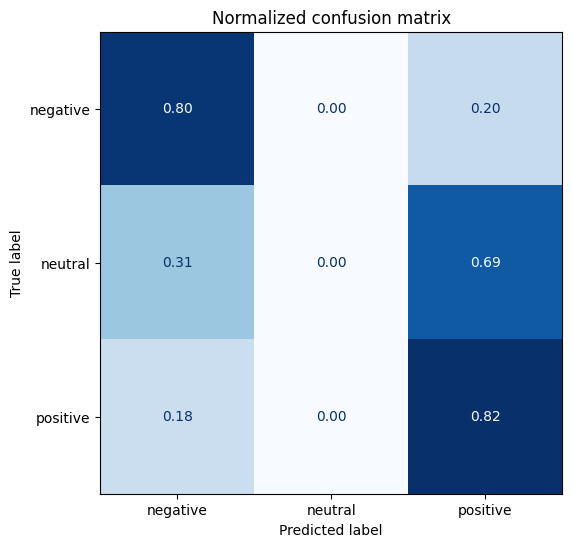

In [ ]:
y_preds = nampluse_lr_clf.predict(X_valid)
plot_confusion_matrix(y_preds, y_valid, labels)

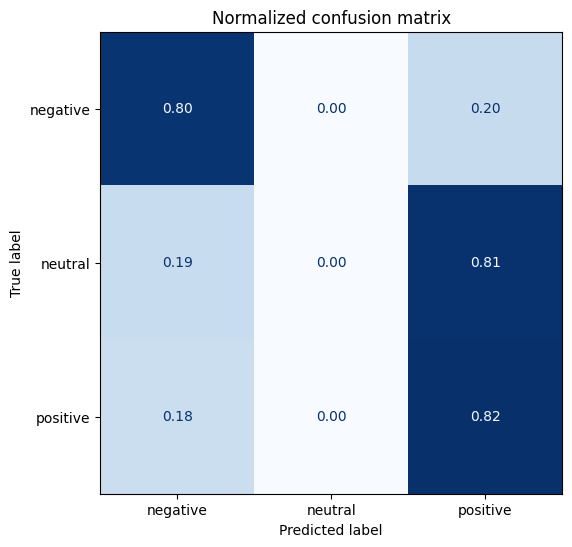

In [ ]:
y_preds_train = nampluse_lr_clf.predict(X_train)
plot_confusion_matrix(y_preds_train, y_train, labels)

In [ ]:
y_preds_train

array(['negative', 'positive', 'positive', ..., 'negative', 'negative',
       'negative'], dtype='<U8')

In [ ]:
# Get predicted probabilities for the validation set
y_probs = lr_clf.predict_proba(X_valid)

# Create a mapping from class name to its index in lr_clf.classes_
class_to_idx = {c: i for i, c in enumerate(lr_clf.classes_)}

# Get the index of the true label for each sample
y_true_idx = [class_to_idx[label] for label in y_valid]

# Calculate cross-entropy loss per sample
# We clip probabilities to prevent log(0) errors
clipped_probs = np.clip(y_probs, 1e-15, 1 - 1e-15)
losses = -np.log(clipped_probs[range(len(clipped_probs)), y_true_idx])

# Create the error analysis DataFrame
df_error_analysis = pd.DataFrame({
    "text": nampluse["validation"]["text"],
    "true_label": y_valid,
    "predicted_label": y_preds,
    "loss": losses
})

# Sort by highest loss to see the model's worst mistakes
df_error_analysis = df_error_analysis.sort_values(by="loss", ascending=False).reset_index(drop=True)

# Display the top 10 most confident incorrect predictions
display(df_error_analysis.head(10))

,text,true_label,predicted_label,loss
0,have google profiles stopped showing up in sea...,neutral,negative,7.350044
1,All of which apply to us - we're basically tex...,negative,positive,7.128250
2,ok.. do nothing.. just thinking about 40D,neutral,positive,6.985983
3,need suggestions for a good IR filter for my c...,neutral,positive,6.789414
4,Saved money by opting for grocery store trip a...,neutral,positive,5.698985
5,I hope the girl at work buys my Kindle2,neutral,positive,5.598167
6,Macbook be3eeda 3any unless I got able to go t...,positive,negative,5.438257
7,Did not realize there is a gym above Safeway!,neutral,negative,5.278202
8,Found a safeway. Picking up a few staples.,neutral,positive,5.118580
9,school sucks... im at school right know and do...,positive,negative,4.823358


In [ ]:
df_error_analysis1 = df_error_analysis.sort_values(by="loss", ascending=True).reset_index(drop=True)

# Display the top 10 most confident correct predictions
display(df_error_analysis1.head(10))

,text,true_label,predicted_label,loss
0,"Sore from work, the extremes of cold, not look...",negative,negative,0.000154
1,I fell yesterday and hurt my knee big time! No...,negative,negative,0.000435
2,FollowFriday is a great woman whose Tweets are...,positive,positive,0.000677
3,My throat is so messed up I can't eat breakfas...,negative,negative,0.000686
4,Feeling like crap Sore throat and a running nose.,negative,negative,0.000845
5,"aghhh...I am so sick!!!! headache, tummy ache,...",negative,negative,0.000845
6,"still bored. didn't make it to the y, again. s...",negative,negative,0.001069
7,link did not work...,negative,negative,0.001308
8,"ugh, that sucks. I feel so bad for you.",negative,negative,0.001310
9,Is up and really not wanting to go to work! Wh...,negative,negative,0.001322


## 8. Baseline Modeling: Support Vector Machine (LinearSVC)
We train a second baseline model, a Linear Support Vector Machine. SVMs are historically very strong on text classification tasks. It performs similarly to Logistic Regression (around 81.2% accuracy).

In [ ]:
from sklearn.svm import LinearSVC

# Initialize LinearSVC. We increase max_iter for convergence.
numpluse_svm_clf = LinearSVC(max_iter=3000, dual=False)
numpluse_svm_clf.fit(X_train, y_train)

# Evaluate the model on the validation set
svm_score = numpluse_svm_clf.score(X_valid, y_valid)
print(f"SVM Validation Accuracy: {svm_score:.4f}")

SVM Validation Accuracy: 0.8120


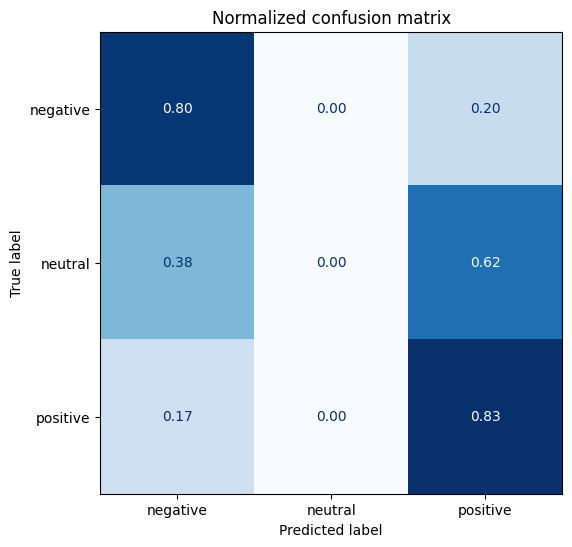

In [ ]:
# Predict on the validation set and plot the confusion matrix
y_preds_svm = numpluse_svm_clf.predict(X_valid)
plot_confusion_matrix(y_preds_svm, y_valid, labels)

In [ ]:

# Create a DataFrame with the validation texts, true labels, and SVM predictions
df_svm_errors = pd.DataFrame({
    "text": nampluse["validation"]["text"],
    "true_label": y_valid,
    "predicted_label": y_preds_svm
})

# Filter for only the incorrect predictions
df_svm_errors = df_svm_errors[df_svm_errors["true_label"] != df_svm_errors["predicted_label"]]

# Show the most common types of errors (confusion pairs)
error_counts = df_svm_errors.groupby(["true_label", "predicted_label"]).size().reset_index(name="count")
error_counts = error_counts.sort_values(by="count", ascending=False)

print("Most frequent SVM misclassifications (True Label -> Predicted Label):")
display(error_counts)

# Look at some specific examples of the most common error
if not error_counts.empty:
    top_error = error_counts.iloc[0]
    print(f"\nExamples where True is '{top_error['true_label']}' but Predicted is '{top_error['predicted_label']}':")

    sample_errors = df_svm_errors[
        (df_svm_errors["true_label"] == top_error['true_label']) &
        (df_svm_errors["predicted_label"] == top_error['predicted_label'])
    ]

    # Display up to 10 examples of this specific error
    display(sample_errors.head(10))

Most frequent SVM misclassifications (True Label -> Predicted Label):


,true_label,predicted_label,count
0,negative,positive,1494
3,positive,negative,1324
2,neutral,positive,10
1,neutral,negative,6



Examples where True is 'negative' but Predicted is 'positive':


,text,true_label,predicted_label
23,Soaked to the skin! Caps off a fine ol morning...,negative,positive
27,that sounds way better than baloney and cheese,negative,positive
37,i gots to work go lakers !,negative,positive
40,nO I didn't... stiLL saD..and piSsed. imma pro...,negative,positive
54,Notes to self: Do not make spaghetti in best w...,negative,positive
64,my mumS DRUNK already,negative,positive
74,PLEASEEE CAN WE MAKE A 5AWESOME_______ CHANNEL??,negative,positive
83,Leaving NYC - heading downtown to catch the e-...,negative,positive
89,goodnight kisses,negative,positive
105,iran f*ck the dictator.,negative,positive


In [ ]:
display(sample_errors.head(10))

,text,true_label,predicted_label
23,Soaked to the skin! Caps off a fine ol morning...,negative,positive
27,that sounds way better than baloney and cheese,negative,positive
37,i gots to work go lakers !,negative,positive
40,nO I didn't... stiLL saD..and piSsed. imma pro...,negative,positive
54,Notes to self: Do not make spaghetti in best w...,negative,positive
64,my mumS DRUNK already,negative,positive
74,PLEASEEE CAN WE MAKE A 5AWESOME_______ CHANNEL??,negative,positive
83,Leaving NYC - heading downtown to catch the e-...,negative,positive
89,goodnight kisses,negative,positive
105,iran f*ck the dictator.,negative,positive


In [ ]:
sample_text = "Damn that is bad, i suggest you use a different approch."

# 1. Tokenize the text
inputs = roberta_tokenizer(sample_text, return_tensors="pt", padding=True, truncation=True)

# Move inputs to the same device as the model (GPU/CPU)
inputs = {k: v.to(device) for k, v in inputs.items()}

# 2. Extract the hidden states
with torch.no_grad():
    outputs = roberta_model(**inputs)

# Get the [CLS] token representation (first token)
hidden_state = outputs.last_hidden_state[:, 0, :].cpu().numpy()

# 3. Predict using both models
lr_pred = nampluse_lr_clf.predict(hidden_state)[0]
svm_pred = numpluse_svm_clf.predict(hidden_state)[0]

print(f"Text: '{sample_text}'\n")
print(f"Logistic Regression Prediction: {lr_pred}")
print(f"SVM Prediction: {svm_pred}")


Text: 'Damn that is bad, i suggest you use a different approch.'

Logistic Regression Prediction: negative
SVM Prediction: negative


In [ ]:
from sklearn.metrics import classification_report

print("=== Logistic Regression Metrics ===")
# We already have y_valid and y_preds from earlier cells
print(classification_report(y_valid, y_preds, target_names=labels))

print("\n" + "="*35 + "\n")

print("=== SVM Metrics ===")
# We already have y_valid and y_preds_svm from earlier cells
print(classification_report(y_valid, y_preds_svm, target_names=labels))


=== Logistic Regression Metrics ===
              precision    recall  f1-score   support

    negative       0.81      0.80      0.81      7492
     neutral       0.00      0.00      0.00        16
    positive       0.80      0.82      0.81      7566

    accuracy                           0.81     15074
   macro avg       0.54      0.54      0.54     15074
weighted avg       0.81      0.81      0.81     15074



=== SVM Metrics ===
              precision    recall  f1-score   support

    negative       0.82      0.80      0.81      7492
     neutral       0.00      0.00      0.00        16
    positive       0.81      0.83      0.82      7566

    accuracy                           0.81     15074
   macro avg       0.54      0.54      0.54     15074
weighted avg       0.81      0.81      0.81     15074



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

In [ ]:
def predict_sentiment(text):
    # 1. Tokenize the text
    inputs = roberta_tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    # Move inputs to the same device as the model (GPU/CPU)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 2. Extract the hidden states
    with torch.no_grad():
        outputs = roberta_model(**inputs)

    # Get the [CLS] token representation (first token)
    hidden_state = outputs.last_hidden_state[:, 0, :].cpu().numpy()

    # 3. Predict using both models
    lr_pred = nampluse_lr_clf.predict(hidden_state)[0]
    svm_pred = numpluse_svm_clf.predict(hidden_state)[0]

    print(f"Text: '{text}'\n")
    print(f"Logistic Regression Prediction: {lr_pred}")
    print(f"SVM Prediction: {svm_pred}")
    print("-" * 40)

    return lr_pred, svm_pred

# Test the function with a few examples
predict_sentiment("Damn that is bad, i suggest you use a different approch.")
predict_sentiment("I saw a movie today and it was really good.")
